In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from datetime import datetime


def plot_asf_timeline(csv_file,
                      earthquake_time=None,
                      earthquake_label="Earthquake",
                      output_file=None):

    df = pd.read_csv(csv_file)

    # ----------------------------------------------------------
    # Find acquisition time column
    # ----------------------------------------------------------

    for col in [
        "Acquisition Date",
        "Start Time",
        "Start Time UTC",
        "Temporal Start",
        "startTime",
    ]:
        if col in df.columns:
            time_col = col
            break
    else:
        raise ValueError("Couldn't find acquisition time column.")

    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(time_col)

    # ----------------------------------------------------------
    # Find track column
    # ----------------------------------------------------------

    for col in [
        "Path Number",
        "Track Number",
        "Relative Orbit",
        "relativeOrbit",
    ]:
        if col in df.columns:
            track_col = col
            break
    else:
        # Put everything on one row if no track information exists
        track_col = "__track__"
        df[track_col] = 1

    # ----------------------------------------------------------
    # Find ascending/descending column
    # ----------------------------------------------------------

    direction_col = None
    for col in [
        "Ascending or Descending?",
        "Orbit Pass",
        "Flight Direction",
        "Pass Direction",
    ]:
        if col in df.columns:
            direction_col = col
            break

    # ----------------------------------------------------------
    # Find granule name column
    # ----------------------------------------------------------

    granule_col = None
    for col in [
        "Granule Name",
        "Granule Name(s)",
        "Scene Name",
        "File ID",
    ]:
        if col in df.columns:
            granule_col = col
            break

    # ----------------------------------------------------------
    # Prepare plotting
    # ----------------------------------------------------------

    tracks = sorted(df[track_col].unique())

    levels = np.arange(len(tracks), 0, -1)
    track_to_level = dict(zip(tracks, levels))

    fig, ax = plt.subplots(figsize=(14,5))

    cmap = plt.get_cmap("bone")
    colors = cmap(np.linspace(
        1/(len(tracks)+1),
        len(tracks)/(len(tracks)+1),
        len(tracks)
    ))

    # ----------------------------------------------------------
    # Plot each track
    # ----------------------------------------------------------

    for (track, subset), color in zip(df.groupby(track_col), colors):

        subset = subset.sort_values(time_col)
        level = track_to_level[track]

        if direction_col is not None:
            direction = subset[direction_col].iloc[0]
            label = f"{direction} Track {track}"
        else:
            label = f"Track {track}"

        ax.plot(
            subset[time_col],
            np.full(len(subset), level),
            "o-",
            lw=2,
            ms=6,
            color=color,
            label=label,
        )

        for date in subset[time_col]:

            ax.text(
                date,
                level+0.08,
                date.strftime("%d-%b"),
                fontsize=10,
                rotation=40,
                color=color,
            )

    # ----------------------------------------------------------
    # Earthquake marker
    # ----------------------------------------------------------

    if earthquake_time is not None:
        ax.axvline(
            earthquake_time,
            color="firebrick",
            lw=2,
            label=earthquake_label,
        )

    # ----------------------------------------------------------
    # Formatting
    # ----------------------------------------------------------

    ax.set_ylim(0, len(tracks)+1)

    ax.yaxis.set_visible(False)

    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))

    ax.grid(which="major", axis="x", alpha=0.4)
    ax.grid(which="minor", axis="x", linestyle=":", alpha=0.2)

    ax.legend(frameon=False)

    plt.tight_layout()

    if output_file is not None:
        plt.savefig(output_file, dpi=300, bbox_inches="tight")

    plt.show()

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/hyin/miniforge3/envs/gmtsar/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 3549, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/x7/q8y3dbkj0gv831q8bnwtym_c0000gp/T/ipykernel_4127/1777308952.py", line 5, in <module>
    plot_asf_timeline(
    ~~~~~~~~~~~~~~~~~^
        f"{path}search_results_nisar.csv",
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        earthquake_time=datetime(2026,6,24,22,4,33),
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        output_file=f"{path}timeline.png",
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/var/folders/x7/q8y3dbkj0gv831q8bnwtym_c0000gp/T/ipykernel_4127/3920011405.py", line 131, in plot_asf_timeline
    date.strftime("%d-%b"),
    ~~~~~~~~~~~~~^^^^^^^^^
  File "nattype.pyx", line 54, in pandas._libs.tslibs.nattype._make_error_func.f
ValueError: NaTType does not

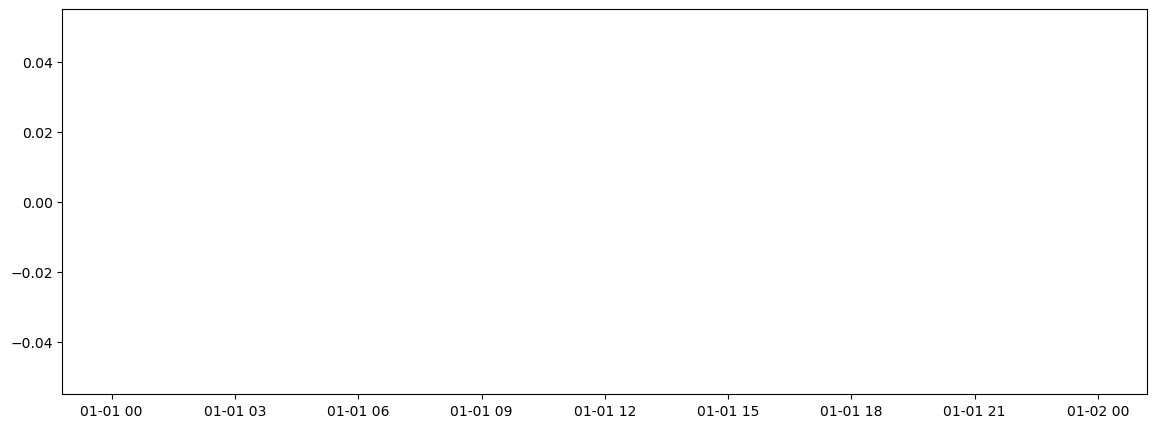

In [2]:
from datetime import datetime

path='/Volumes/T9_InSAR/2026-07-28_kumamoto/'

plot_asf_timeline(
    f"{path}search_results_nisar.csv",
    earthquake_time=datetime(2026,6,24,22,4,33),
    output_file=f"{path}timeline.png",
)